In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    roc_curve,
    classification_report, 
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [184]:
df = pd.read_csv("S05-hw-dataset.csv")

In [186]:
display(df.head())

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [188]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [211]:
display(df.describe())

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


Распределение целевой переменной 'default':
default
0    0.589667
1    0.410333
Name: proportion, dtype: float64


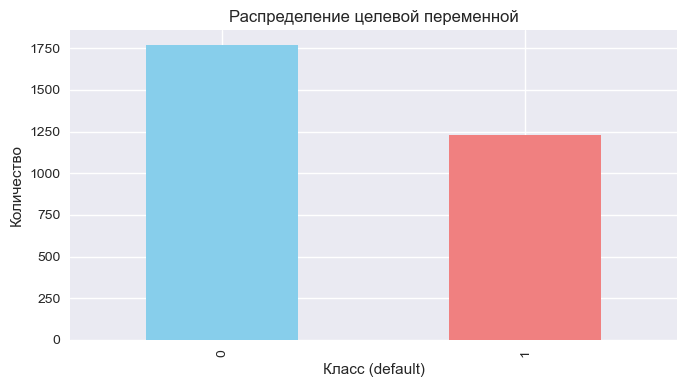

In [190]:
print("Распределение целевой переменной 'default':")
print(df['default'].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(7, 4))
df['default'].value_counts().plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
ax.set_title('Распределение целевой переменной')
ax.set_xlabel('Класс (default)')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

Датасет содержит 3000 наблюдений (строк) и 17 признаков (столбцов). Явных аномалий, таких как невозможные значения в ключевых признаках (отрицательный доход, возраст вне разумных пределов и т.д.), не обнаружено. Целевая переменная распределена с долей дефолтов 41% против 59% случаев без дефолта, что указывает на умеренную несбалансированность классов. Все признаки числовые, пропущенные значения отсутствуют.

In [194]:
X = df.drop(columns=['client_id', 'default'])
y = df['default']

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")
print(f"\nПервые признаки: {list(X.columns[:5])}...")
print(f"\nПроверка debt_to_income в [0, 1]: "
      f"{(X['debt_to_income'] >= 0).all() and (X['debt_to_income'] <= 1).all()}")

X.shape: (3000, 15)
y.shape: (3000,)

Первые признаки: ['age', 'income', 'years_employed', 'credit_score', 'debt_to_income']...

Проверка debt_to_income в [0, 1]: True


In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

In [197]:
baseline = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline)

print(f"Бейзлайн-модель (DummyClassifier, strategy='stratified'):")
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"ROC-AUC:  {roc_auc_baseline:.4f}")

Бейзлайн-модель (DummyClassifier, strategy='stratified'):
Accuracy: 0.5400
ROC-AUC:  0.5246


Бейзлайн предсказывает классы случайно с учётом распределения классов в данных. \
Бейзлайн важен как минимальная планка качества: если модель не превосходит его, она не извлекает полезных закономерностей.

In [202]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Лучший параметр C: {grid_search.best_params_['logreg__C']}")
print(f"Лучший ROC-AUC (кросс-валидация): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Лучший параметр C: 0.01
Лучший ROC-AUC (кросс-валидация): 0.8631


In [203]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Метрики
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Лучшая модель на тестовой выборке:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Лучшая модель на тестовой выборке:
Accuracy:  0.7840
ROC-AUC:   0.8641


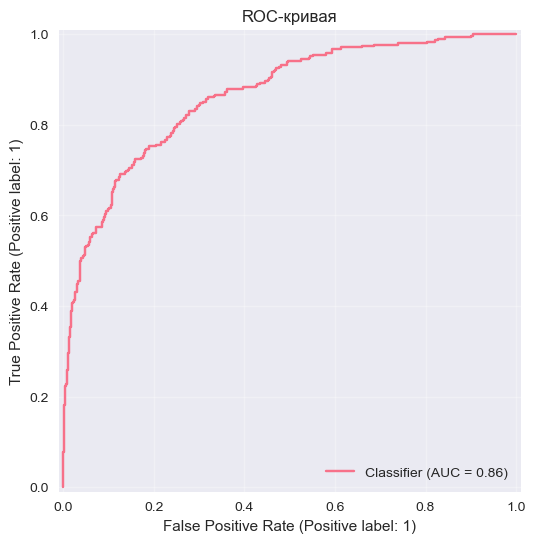

In [204]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC-кривая')
plt.grid(True, alpha=0.3)
plt.savefig('figures/roc_curve.png')
plt.show()

In [205]:
comparison_df = pd.DataFrame({
    'Модель': ['Бейзлайн', 'Логистическая регрессия'],
    'Accuracy': [accuracy_strat, accuracy_logreg],
    'ROC-AUC': [roc_auc_strat, roc_auc_logreg]
})
print("\nТаблица сравнения:")
display(comparison_df)


Таблица сравнения:


,Модель,Accuracy,ROC-AUC
0,Бейзлайн,0.540,0.524586
1,Логистическая регрессия,0.784,0.864062


Логистическая регрессия значительно превосходит бейзлайн-модель по качеству. Accuracy вырос с 0.540 до 0.784 (улучшение на 45%), а ROC-AUC увеличился с 0.525 до 0.864 (рост на 65%). При подборе параметра регуляризации C было установлено, что оптимальное значение обеспечивает хороший баланс между обучением и обобщением.

Для данной задачи предсказания дефолта логистическая регрессия показывает разумные результаты. Модель демонстрирует хорошую разделяющую способность (ROC-AUC > 0.86) и может быть использована для начальной оценки кредитных рисков. Бейзлайн служит важной контрольной точкой, подтверждая что логистическая регрессия извлекает полезные закономерности из данных.

